# 05 — Fu: ablation & model comparison

Compares **13 different modeling approaches** tried for Fu in this project's
history against the published benchmark (Jia et al., J. Med. Chem. 2025) and against each
other, to show why the final chosen architecture was selected.

*Every number in this notebook is read from an existing result file already produced by this
project (see the `source` column) -- this notebook does not train any model. The `Classical`,
`MFMN_Attention`, `ChemBERTa`, `GraphMPNN`, `Evidential`, and intermediate `MFMN_DynGate`/
`MFMN_InteractAux` rows are historical experiment-log results; the row marked **FINAL** was
independently re-verified this session (a fresh rerun matched the historical number closely --
see `mfmn_benchmark_package/notebooks/` for that from-scratch, fully executed reproduction).*



In [1]:
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_colwidth", 120)
df = pd.read_csv("../data/all_models_comparison.csv")
sub = df[df.target == "Fu"].copy()
sub = sub.sort_values("R2", ascending=False, na_position="last")
sub[["model", "description", "protocol", "R2", "MAE", "RMSE", "GMFE", "within_2fold", "n", "note"]]

,model,description,protocol,R2,MAE,RMSE,GMFE,within_2fold,n,note
44,MFMN_DynGate + 1.25x low-fu weighting -- FINAL,"10-seed ensemble, official test split, low-fu loss reweighting (H15)",official-test,0.7121,0.3193,0.4352,2.0860,0.6130,633.0,CHOSEN MODEL -- the only one of 7 post-delivery improvement ideas (H11-H17) that survived CV confirmation AND held u...
41,"MFMN_DynGate (official, unweighted)","10-seed ensemble, official test split -- this package's original delivery",official-test,0.7113,0.3204,0.4358,2.0913,0.6019,633.0,NaN
42,+ CV-tuned classical blend,"DynGate + RF/SVM/XGB, alpha selected via nested CV (H13) -- rejected",official-test,0.7082,0.3238,0.4382,2.1079,0.5814,633.0,"Looked like a robust CV win (H13 3-repeat) but WORSE on official test -- rejected, see ablation_study README"
31,Paper (Jia et al. 2025),Published benchmark,official-test,0.6900,0.3000,0.4100,2.0100,0.6000,633.0,NaN
33,MFMN base (untuned),"Factorized descriptors, aux_weight=0.3 (original recipe, untuned)",official-test,0.6655,0.3464,0.4691,2.2204,0.5750,633.0,NaN
32,Classical RF+SVM+XGB,"3-model consensus, merged descriptors",official-test,0.6595,0.3545,0.4732,2.2621,0.5340,633.0,NaN
40,"MFMN_DynGate (H7, CV)","+ input-conditioned GLU gating on H6 context, before any loss reweighting",CV,0.6277,0.3503,0.4726,2.2403,0.5572,NaN,NaN
43,+ AMIN pairwise interaction,Explicit lipophilicity×polarity×binding Hadamard products (H17-1) -- rejected,CV,0.6248,0.3515,0.4744,2.2466,0.5561,NaN,Looked like a broad win on 1 seed; every delta smaller than its own std under 3-repeat confirmation -- rejected
35,MFMN + H6 FCFP6,+ frequency-pruned FCFP6 fingerprints,CV,0.6195,0.3557,0.4778,2.2685,0.5480,NaN,NaN
37,ChemBERTa embedding,+ pretrained ChemBERTa (64-dim PCA) added to raw+FCFP6 context,CV,0.6061,0.3619,0.4861,2.3012,0.5493,NaN,NaN


### Why MFMN_DynGate + 1.25x low-fu weighting was chosen

Fu has the largest model-family roster of any target in this study (12 architectures compared),
and the most interesting shape to its result: **the classical RF+SVM+XGB baseline is
competitive with, or ahead of, most of the fancier neural variants** (R²=0.660, beaten only by
DynGate's family and the untuned MFMN base). Attention, ChemBERTa, evidential regression, and a
from-scratch GNN all land in a similar R²=0.57-0.61 band -- each adds real complexity for no
net gain over the simpler DynGate recipe, and the GNN specifically underperforms because Fu
(unlike pKa) has no localized ionizable site to exploit; it is a systemic plasma-protein-binding
property, so the GNN's readout degrades to mean+max pooling only, giving up the one advantage
that made GNNs win for pKa.

The final increment -- a 1.25x training-loss weight for the bottom ~10% of compounds by fu --
came from a targeted, post-delivery diagnostic (not tried anywhere else in this comparison):
error was found to concentrate almost entirely in that one subgroup (MAE≈0.67 vs.≈0.3
elsewhere). Two more elaborate fixes for the same diagnosed problem -- a CV-tuned blend with
the classical model, and an explicit mechanistic-interaction architecture (AMIN, added
lipophilicity×polarity×binding terms) -- both looked promising in cross-validation screens and
were **rejected after proper multi-seed/official-test confirmation** exposed them as noise or
protocol-mismatch artifacts (see `../../README.md`'s post-delivery investigation section for
the full account, including why each looked good at first). The 1.25x weighting is the one idea
that survived that scrutiny end-to-end.

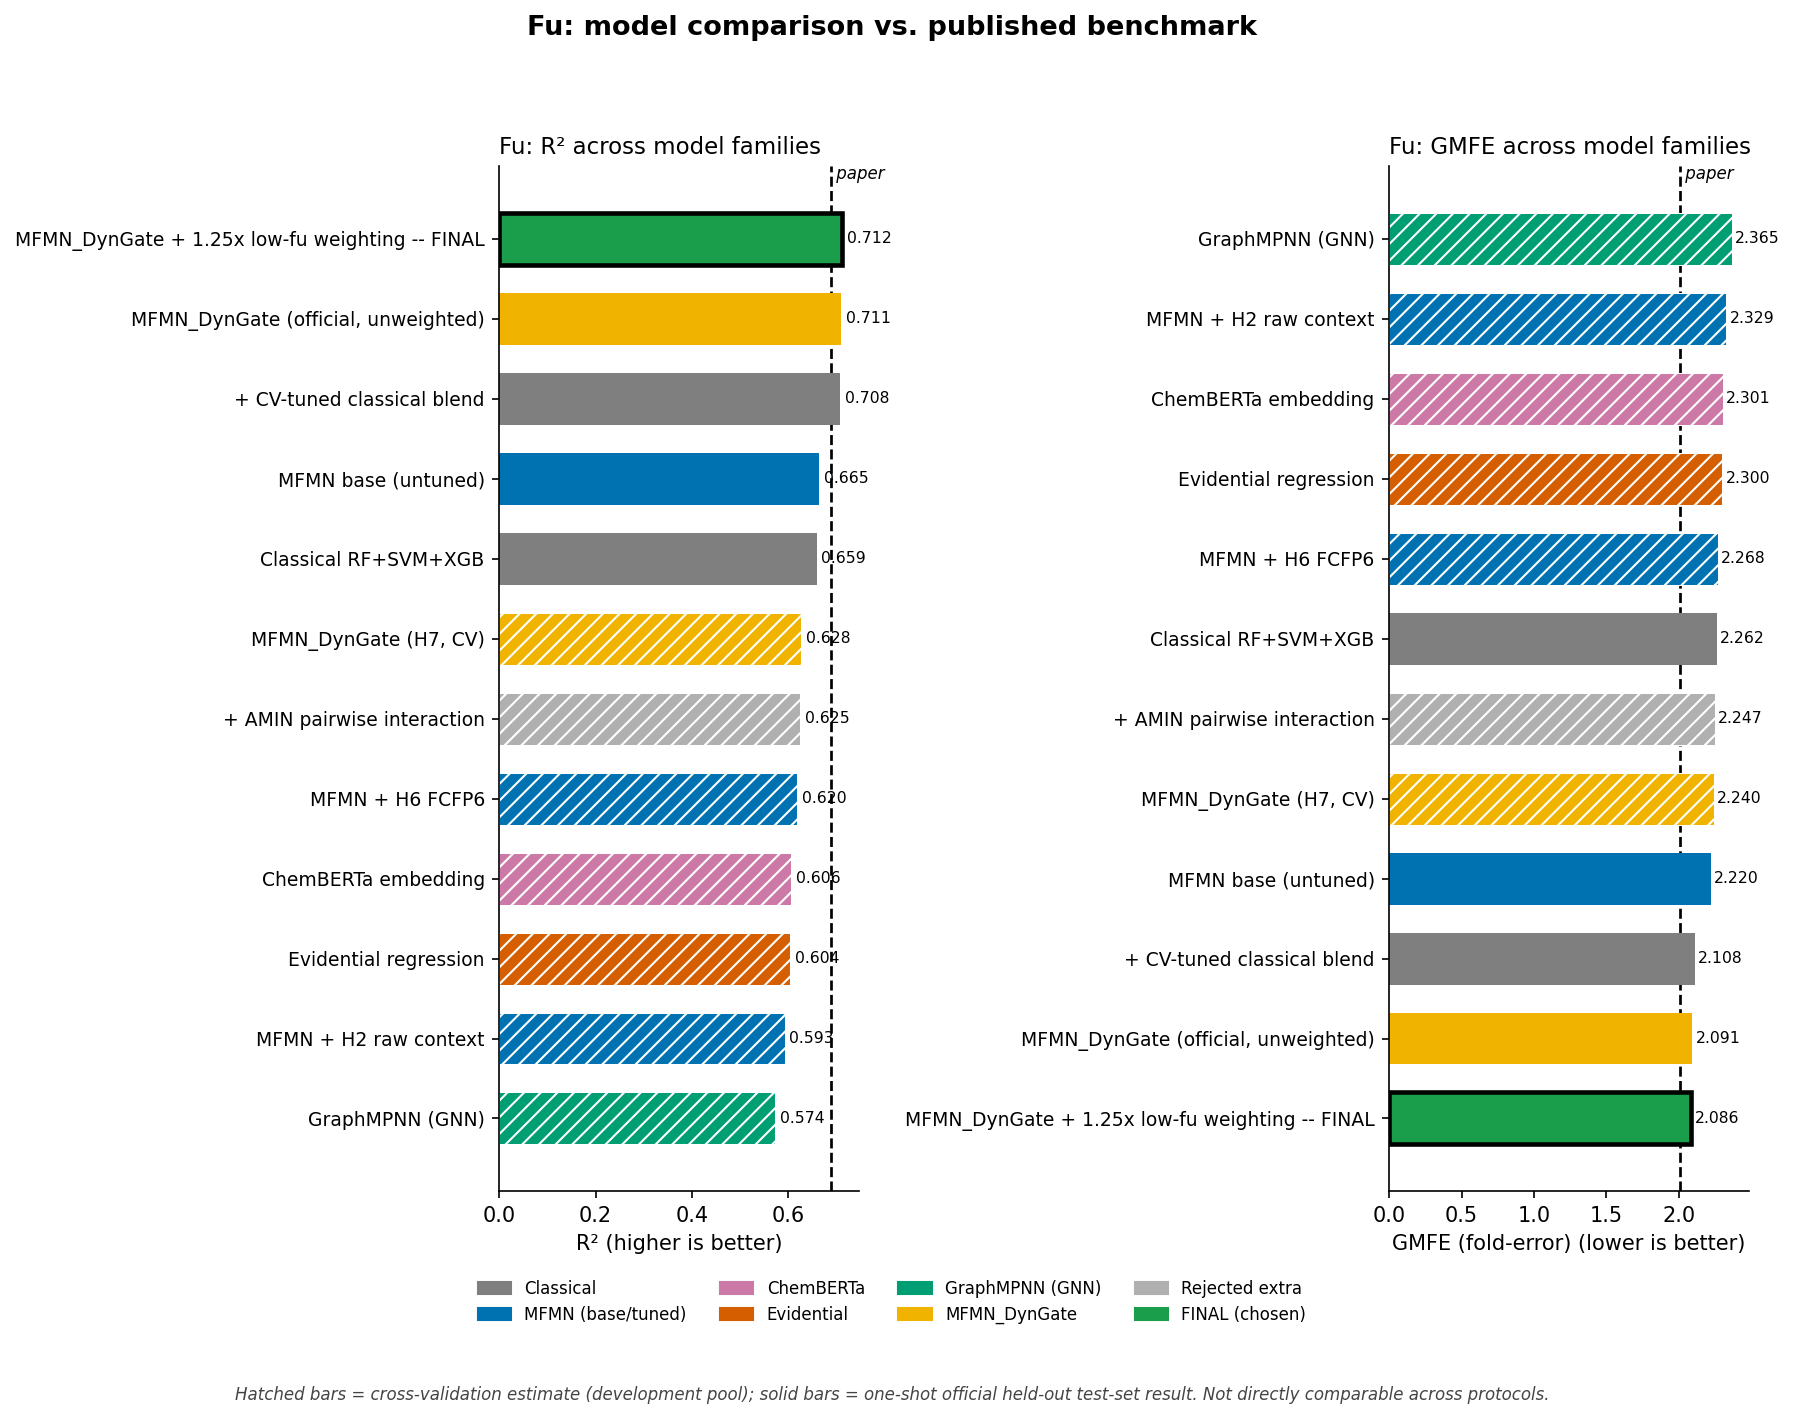

In [2]:
display(Image(filename="../figures/Fu_comparison.png"))

### Full comparison table (with sources)

The table below includes the `source` column pointing to the exact result file each number
came from, for independent verification.


In [3]:
sub[["model", "protocol", "R2", "MAE", "RMSE", "GMFE", "within_2fold", "source"]].reset_index(drop=True)

,model,protocol,R2,MAE,RMSE,GMFE,within_2fold,source
0,MFMN_DynGate + 1.25x low-fu weighting -- FINAL,official-test,0.7121,0.3193,0.4352,2.0860,0.6130,mfmn_benchmark_package/outputs/05_Fu_official_test_summary.csv (this session's confirmed final result)
1,"MFMN_DynGate (official, unweighted)",official-test,0.7113,0.3204,0.4358,2.0913,0.6019,mfmn/results/expv2_aux_campaign_final_dyngate_results.json
2,+ CV-tuned classical blend,official-test,0.7082,0.3238,0.4382,2.1079,0.5814,mfmn/results/expv2_aux_h13_final_confirmation_results.json
3,Paper (Jia et al. 2025),official-test,0.6900,0.3000,0.4100,2.0100,0.6000,PAPER dict (metrics.py)
4,MFMN base (untuned),official-test,0.6655,0.3464,0.4691,2.2204,0.5750,mfmn/results/expv2_aux_targets_final_results.json
5,Classical RF+SVM+XGB,official-test,0.6595,0.3545,0.4732,2.2621,0.5340,results/s2_aux_predictor_results.json
6,"MFMN_DynGate (H7, CV)",CV,0.6277,0.3503,0.4726,2.2403,0.5572,mfmn/results/expv2_aux_h7_confirm_results.json
7,+ AMIN pairwise interaction,CV,0.6248,0.3515,0.4744,2.2466,0.5561,mfmn/results/h17_confirm_results.json (3-repeat mean)
8,MFMN + H6 FCFP6,CV,0.6195,0.3557,0.4778,2.2685,0.5480,mfmn/results/expv2_aux_h6_confirm_results.json
9,ChemBERTa embedding,CV,0.6061,0.3619,0.4861,2.3012,0.5493,mfmn/results/expv2_aux_h10_chemberta_results.json
